## Spam Email Classifier

### Testing different approach for finding the best model.
Here we've downloaded the dataset from **kaggle** which has around `5K` samples.

In [1]:
# import necessary lib's

import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (accuracy_score, 
                                f1_score,
                                precision_score,
                                recall_score)

**Since, we're doing this project after learning `LogisticRegression` therefore we only use `LogisticRegression` classifier only.**
<br/>
Later, In this 45 Days Journey, we perform comparitive study all the classification models and find out the best model for this task.

In [2]:
# only LogisticRegression classifier

from sklearn.linear_model import LogisticRegression

### Loading dataset

In [3]:
DATASET_PATH = r"E:\45DaysML\projects\spam-email-classifier\data\dataset.csv"

data = pd.read_csv(DATASET_PATH)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### How our data samples looks like?

In [4]:
data.sample(5)

,Category,Message
2433,ham,Indians r poor but India is not a poor country...
3349,ham,Sorry i cant take your call right now. It so h...
3423,spam,Am new 2 club & dont fink we met yet Will B gr...
2979,ham,What u mean u almost done? Done wif sleeping? ...
5257,ham,"As usual..iam fine, happy &amp; doing well..:)"


In [5]:
rows, cols = data.shape

print("Total no. of ROWS: {} and Columns: {}".format(rows, cols))

Total no. of ROWS: 5572 and Columns: 2


<Axes: xlabel='Category'>

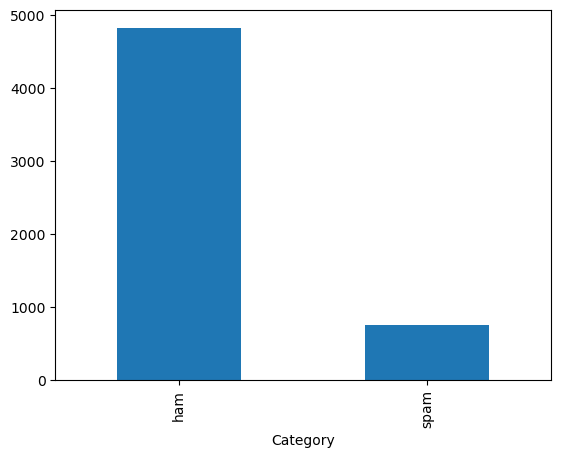

In [6]:
# Visualizing the distribution of target column
data.Category.value_counts().plot(kind='bar')

We can clearly see that, This data is *imbalanced*, for dealing with this imbalance data classification we use *weight_assignment* technique, here *Higher** class datapoints gets lower wt. values and *Lower* class datapoints gets *higher* wt. values.

### Data Preprocessing 

**Step 1:** Check for `nan` column values and remove them.

In [7]:
data.isna().sum()

Category    0
Message     0
dtype: int64

Clearly, We can see that there are no `nan` values in the above data.
<br/>
Now, we preprocess `Category` column, replace **spam** with value `1` and **ham** with value `0`.

In [16]:
data.loc[data['Category'] == 'spam', 'Category',] = 1
data.loc[data['Category'] == 'ham', 'Category',] = 0

In [17]:
data["Category"].value_counts()

Category
1    4825
0     747
Name: count, dtype: int64

In [18]:
X = data["Message"]
y = data["Category"]

### Split dataset for training and testing

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=32,
                                                    test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3900,), (1672,), (3900,), (1672,))

### Apply TfidfVectorizer

In [23]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words="english", lowercase=True)

In [30]:
X_train_features = feature_extraction.fit_transform(X_train).toarray()
X_test_features = feature_extraction.transform(X_test).toarray()

In [36]:
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)

### Model training 

In [39]:
logistic_regression_clf = LogisticRegression(n_jobs=-1,
                                             class_weight='balanced')
logistic_regression_clf.fit(X_train_features, y_train)

LogisticRegression(class_weight='balanced', n_jobs=-1)

In [40]:
logistic_regression_predictions = logistic_regression_clf.predict(X_test_features)

### Evaluation 

In [43]:
print(f"F1 Score: {f1_score(
    y_test, logistic_regression_predictions
):.5f}\nRecall Score: {(recall_score(
    y_test, logistic_regression_predictions
)):.5f}\nPrecision Score: {precision_score(
    y_test, logistic_regression_predictions
):.5f}\nAccuracy Score: {accuracy_score(
    y_test, logistic_regression_predictions
):.5f}")

F1 Score: 0.99209
Recall Score: 0.99449
Precision Score: 0.98971
Accuracy Score: 0.98624
